# Module 3: Data Center Project - Python

<a target="_blank" href="https://colab.research.google.com/github/yalinli2/EnvEtools/blob/main/course_modules/3_Data_Center_Project_Python.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https:///mybinder.org/v2/gh/yalinli2/EnvEtools/main?urlpath=%2Fdoc%2Ftree%2Fcourse_modules%2F3_Data_Center_Project_Python.ipynb">
  <img src="https://mybinder.org/badge_logo.svg" alt="Open In Binder"/>
</a>

## Example Workflow
* Import data center information from [Data Center Map](www.datacentermap.com) (Excel, MATLAB, Python).
* Clean-up/extract addresses (Excel, MATLAB, Python).
* Download and extract drought data from [Drought Monitor](https://droughtmonitor.unl.edu) (Excel, MATLAB, Python).
* Download and extract electricity generation and emission data from [eGRID](https://www.epa.gov/egrid/detailed-data) (Excel, MATLAB, Python).
* Superimpose data center location and water/energy data (GIS, tableau).

## Collect Data Center Information

### Download Data

If you observe the link url closely, you can find they follow the pattern of

https://www.datacentermap.com/usa/{state}/{location}/

For example, 

https://www.datacentermap.com/usa/new-jersey/secaucus/

So we can relatively pull the data for all locations in a certain state. I will use NJ as the example for the demonstration.

### Compile Data

Once we have all data downloaded, we can use Python to compile and extract the information we want.

In [1]:
# Import the Excel
import pandas as pd
path = '../data/3_DataCenterNJtop5.xlsx'
sheet_dct = {}
datacenter = pd.read_excel(path, sheet_name=None)

In [2]:
# The imported file is a dictionary with sheet name as the keys, and sheet content as dataframes as values
datacenter

{'1_Hudson-County':                               Column1  \
 0           100 Delawanna Ave (EWR20)   
 1              2 Peekay Drive (EWR21)   
 2                        DataVerge NJ   
 3        365 Data Centers - Carlstadt   
 4        365 Data Centers - Weehawken   
 5                         Equinix NY7   
 6               QTS Jersey City 1 DC1   
 7        Centersquare - New York EWR1   
 8             11:11 Systems Carlstadt   
 9                 One Evertrust Plaza   
 10  Centersquare  - New York EWR2-A,B   
 11   Centersquare - New York EWR2-C,D   
 12                        Equinix NY6   
 13           Newport Financial Center   
 14                  Lumen Weehawken 1   
 15                  Lumen Jersey City   
 
                                               Column2  \
 0   Digital Realty100 Delawanna Ave07014 CliftonNe...   
 1   Digital Realty2 Peekay Drive07014 CliftonNew J...   
 2   DataVerge111 Town Square Place07310 Jersey Cit...   
 3   365 Data Centers410 Commerce

In [3]:
# Let's look at the first sheet, Hudson County
hudson = datacenter['1_Hudson-County']
hudson.head() # `head` shows the first five rows, `tail` shows the last five rows

,Column1,Column2,Column3
0,100 Delawanna Ave (EWR20),Digital Realty100 Delawanna Ave07014 CliftonNe...,"100 Delawanna Avenue in Clifton, NJ is one of ..."
1,2 Peekay Drive (EWR21),Digital Realty2 Peekay Drive07014 CliftonNew J...,Digital Realty's data center at 2 Peekay Drive...
2,DataVerge NJ,DataVerge111 Town Square Place07310 Jersey Cit...,DataVerge is the partner of choice when it com...
3,365 Data Centers - Carlstadt,365 Data Centers410 Commerce Blvd07072 Carlsta...,"Our Data Center in Carlstadt, NJ, just ten mil..."
4,365 Data Centers - Weehawken,365 Data Centers300 Boulevard East07086 Weehaw...,EWR1 Internet Data Center - High-density racks...


In [4]:
# Our goal is to extract the location information for each entry, so that we will be able to plot the data centers on a map
# We can see that Column2 has the information, but we need to separate it out
for i in hudson.Column2: print(i)

Digital Realty100 Delawanna Ave07014 CliftonNew Jersey, USA
Digital Realty2 Peekay Drive07014 CliftonNew Jersey, USA
DataVerge111 Town Square Place07310 Jersey CityNew Jersey, USA
365 Data Centers410 Commerce Blvd07072 CarlstadtNew Jersey, USA
365 Data Centers300 Boulevard East07086 WeehawkenNew Jersey, USA
Equinix5851 Westside Avenue07047 North BergenNew Jersey, USA
QTS Data Centers95 Christopher Columbus Dr07302 Jersey CityNew Jersey, USA
Centersquare210 Hudson Street07302 Jersey CityNew Jersey, USA
11:11 Systems777 Central Blvd07072 CarlstadtNew Jersey, USA
Unknown Company1 Evertrust Plaza07302 Jersey CityNew Jersey, USA
Centersquare300 JFK Blvd E07086 WeehawkenNew Jersey, USA
Centersquare1919 Park Ave07086 WeehawkenNew Jersey, USA
Equinix105 Enterprise Avenue South7094 SecaucusNew Jersey, USA
Unknown Company111 Town Square Place07310 Jersey CityNew Jersey, USA
Lumen300 Boulevard East07086 WeehawkenNew Jersey, USA
Lumen1 Evertrust Plaza07302 Jersey CityNew Jersey, USA


In [5]:
# Our goal is to extract the zipcode for each entry, so that we will be able to plot the data center location on a map
# We can see that Column2 has the zipcode information, but we need to extract it out
for i in hudson.Column2: print(i)

Digital Realty100 Delawanna Ave07014 CliftonNew Jersey, USA
Digital Realty2 Peekay Drive07014 CliftonNew Jersey, USA
DataVerge111 Town Square Place07310 Jersey CityNew Jersey, USA
365 Data Centers410 Commerce Blvd07072 CarlstadtNew Jersey, USA
365 Data Centers300 Boulevard East07086 WeehawkenNew Jersey, USA
Equinix5851 Westside Avenue07047 North BergenNew Jersey, USA
QTS Data Centers95 Christopher Columbus Dr07302 Jersey CityNew Jersey, USA
Centersquare210 Hudson Street07302 Jersey CityNew Jersey, USA
11:11 Systems777 Central Blvd07072 CarlstadtNew Jersey, USA
Unknown Company1 Evertrust Plaza07302 Jersey CityNew Jersey, USA
Centersquare300 JFK Blvd E07086 WeehawkenNew Jersey, USA
Centersquare1919 Park Ave07086 WeehawkenNew Jersey, USA
Equinix105 Enterprise Avenue South7094 SecaucusNew Jersey, USA
Unknown Company111 Town Square Place07310 Jersey CityNew Jersey, USA
Lumen300 Boulevard East07086 WeehawkenNew Jersey, USA
Lumen1 Evertrust Plaza07302 Jersey CityNew Jersey, USA


In [6]:
# There are many different ways to do it, my method may not be the best one
# The key thing is just to identify the patterns
# We can see that the address starts with a company name, then the street number, street name, zipcode, city name, finally ends with "New Jersey, USA"

# Let's start with the first address
address = 'Digital Realty100 Delawanna Ave07014 CliftonNew Jersey, USA'

# We first separate the "New Jersey, USA" part from the text
address = address.replace('New Jersey, USA', '')
text_lst = address.split(' ')

In [7]:
# We first need to find out a way to split the number from the text
import re
text = 'Realty100'
m = re.match(r'([A-Za-z.-]*?)(\d.*)', text) # this find the first digit after text, then split, "." and "-" is for "Ave.", "US-22", etc.
if m:
    text_part = m.group(1)
    number_part = m.group(2)
print(text_part)   
print(number_part)

Realty
100


In [8]:
# We can make a function to do this
def split_number_from_letter(text):
    m = re.match(r'([A-Za-z.-]*?)(\d.*)', text) # this find the first digit after text, then split, "." and "-" is for "Ave.", "US-22"
    if m:
        word = m.group(1)
        number = m.group(2)
        if len(word)>0 and len(number)>0:
            return word, number
    return text

In [9]:
# The first letter-number mashed component separate the company name from the street number,
# the second mashed component separate the zipcode from the end of the street
splitted_text = []
for text in text_lst:
    splitted = split_number_from_letter(text)
    splitted_text.append(splitted)
splitted_text

['Digital', ('Realty', '100'), 'Delawanna', ('Ave', '07014'), 'Clifton']

In [10]:
# Now we just need to re-assemble text
output = []
chunk = ''
for text in splitted_text:
    if chunk: chunk = chunk + ' ' # add a space
    if isinstance(text, str):
        chunk += text
    else:
        word, number = text
        chunk += word
        output.append(f'{chunk}')
        chunk = number
# The last part is zipcode and city name
m = re.match(r"(\d+)\s+(.*)", chunk)
output.append(m.group(1))
output.append(m.group(2))
output

['Digital Realty', '100 Delawanna Ave', '07014', 'Clifton']

In [11]:
# Putting together everything in one function and give it a try
def organize_address(address):
    address = address.replace('New Jersey, USA', '')
    text_lst = address.split(' ')
    splitted_text = []
    for text in text_lst:        
        splitted = split_number_from_letter(text)
        splitted_text.append(splitted)
    output = []
    chunk = ''
    for text in splitted_text:
        if chunk: chunk = chunk + ' ' # add a space
        if isinstance(text, str):
            chunk += text
        else:
            word, number = text
            chunk += word
            output.append(f'{chunk}')
            chunk = number
    # The last part is zipcode and city name
    m = re.match(r"(\d+)\s+(.*)", chunk)
    zipcode, city = m.group(1), m.group(2)
    if len(zipcode)>5: 
        output[-1] += zipcode[:-5] # for text like 'US-22008876'
        zipcode = zipcode[-5:]
    output.append(zipcode)
    output.append(city)
    return output
organize_address(address)

['Digital Realty', '100 Delawanna Ave', '07014', 'Clifton']

In [12]:
# Now we need to apply this function to all the addresses
# Take the Hudson County as an example
hudson['Splitted_Address'] = hudson.Column2.apply(organize_address)
for i in hudson.Splitted_Address: print(i)

['Digital Realty', '100 Delawanna Ave', '07014', 'Clifton']
['Digital Realty', '2 Peekay Drive', '07014', 'Clifton']
['DataVerge', '111 Town Square Place', '07310', 'Jersey City']
['365 Data Centers', '410 Commerce Blvd', '07072', 'Carlstadt']
['365 Data Centers', '300 Boulevard East', '07086', 'Weehawken']
['Equinix', '5851 Westside Avenue', '07047', 'North Bergen']
['QTS Data Centers', '95 Christopher Columbus Dr', '07302', 'Jersey City']
['Centersquare', '210 Hudson Street', '07302', 'Jersey City']
['11:11 Systems', '777 Central Blvd', '07072', 'Carlstadt']
['Unknown Company', '1 Evertrust Plaza', '07302', 'Jersey City']
['Centersquare', '300 JFK Blvd E', '07086', 'Weehawken']
['Centersquare', '1919 Park Ave', '07086', 'Weehawken']
['Equinix', '105 Enterprise Avenue South', '7094', 'Secaucus']
['Unknown Company', '111 Town Square Place', '07310', 'Jersey City']
['Lumen', '300 Boulevard East', '07086', 'Weehawken']
['Lumen', '1 Evertrust Plaza', '07302', 'Jersey City']


In [13]:
# It worked, so iterating it through all sheets
address_sheets = {}
for location, sheet in datacenter.items():
    location = location.split('_')[-1].replace('-County', '') # turn "1_Hudson-County" into the nicer "Hudson"
    sheet['Splitted_Address'] = sheet.Column2.apply(organize_address)
    new_sheet = pd.DataFrame({
        'Location': location,
        'Company': [i[0] for i in sheet.Splitted_Address],
        'Address': [i[-3] for i in sheet.Splitted_Address],
        'Zipcode': [i[-2] for i in sheet.Splitted_Address],
        'City': [i[-1] for i in sheet.Splitted_Address],
        'State': 'New Jersey',
        'Country': 'USA',
    })
    address_sheets[location] = new_sheet

In [14]:
# Concatenate all sheets together
# ignore_index is to re-index the dataframe, try not setting it to see what it does
# Note that there might still be some errors in the splitted text,
# but it's more or less sufficient for our purposes
datacenter_df = pd.concat(address_sheets.values(), ignore_index=True)
datacenter_df.head()

,Location,Company,Address,Zipcode,City,State,Country
0,Hudson,Digital Realty,100 Delawanna Ave,07014,Clifton,New Jersey,USA
1,Hudson,Digital Realty,2 Peekay Drive,07014,Clifton,New Jersey,USA
2,Hudson,DataVerge,111 Town Square Place,07310,Jersey City,New Jersey,USA
3,Hudson,365 Data Centers,410 Commerce Blvd,07072,Carlstadt,New Jersey,USA
4,Hudson,365 Data Centers,300 Boulevard East,07086,Weehawken,New Jersey,USA


In [15]:
# Export the data so we can use it later
datacenter_df.to_csv('../data/3_DataCenterNJtop5_processed.csv')

## Collect Drought Data

We will use drought data to represent water availability. You can easily download the drought data from [Drought Monitor](https://droughtmonitor.unl.edu).

You can use whatever data you think reasonable to indicate drought severity, for this illustrative example, because it's in NJ, I will use drought data in NJ counties for the past 5 years, which can be found under Data/Data Download/Comprehensive Statistics

<img src='../images/3_drought_monitor.png' alt='Drought Monitor'/>

In [16]:
# Import data to see what it looks like
drought = pd.read_csv('../data/3_DroughtMonitorNJ.csv')
drought.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
0,20251118,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-18,2025-11-24,2
1,20251111,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-11,2025-11-17,2
2,20251104,34001,Atlantic County,NJ,83.87,16.13,0.0,0.0,0.0,0.0,2025-11-04,2025-11-10,2
3,20251028,34001,Atlantic County,NJ,84.84,15.16,0.0,0.0,0.0,0.0,2025-10-28,2025-11-03,2
4,20251021,34001,Atlantic County,NJ,87.91,12.09,0.0,0.0,0.0,0.0,2025-10-21,2025-10-27,2


Since there are 5 different levels (D0 doesn't mean there's no drought), let's use weighted sum as a single indicator, [Drought Severity and Coverage Index](https://droughtmonitor.unl.edu/About/AbouttheData/DSCI.aspx), to represent the total severity.

$$DSCI = D0*1+D1*2+D2*3+D3*4+D4*5$$

In [17]:
drought['DSCI'] = drought.D0*1+drought.D1*2+drought.D2*3+drought.D3*4+drought.D4*5
drought.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID,DSCI
0,20251118,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-18,2025-11-24,2,16.08
1,20251111,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-11,2025-11-17,2,16.08
2,20251104,34001,Atlantic County,NJ,83.87,16.13,0.0,0.0,0.0,0.0,2025-11-04,2025-11-10,2,16.13
3,20251028,34001,Atlantic County,NJ,84.84,15.16,0.0,0.0,0.0,0.0,2025-10-28,2025-11-03,2,15.16
4,20251021,34001,Atlantic County,NJ,87.91,12.09,0.0,0.0,0.0,0.0,2025-10-21,2025-10-27,2,12.09


In [18]:
# Since we have weekly data over 5 years, we'd like to calculate the average for each county
# First we need to get the names of all counties
counties = drought.County.unique()
counties

array(['Atlantic County', 'Bergen County', 'Burlington County',
       'Camden County', 'Cape May County', 'Cumberland County',
       'Essex County', 'Gloucester County', 'Hudson County',
       'Hunterdon County', 'Mercer County', 'Middlesex County',
       'Monmouth County', 'Morris County', 'Ocean County',
       'Passaic County', 'Salem County', 'Somerset County',
       'Sussex County', 'Union County', 'Warren County'], dtype=object)

In [19]:
# Remove the excess "County" in the name
def remove_county(name):
    return name.replace(" County", "")
drought['County'] = drought.County.apply(remove_county)
counties = drought.County.unique()
counties

array(['Atlantic', 'Bergen', 'Burlington', 'Camden', 'Cape May',
       'Cumberland', 'Essex', 'Gloucester', 'Hudson', 'Hunterdon',
       'Mercer', 'Middlesex', 'Monmouth', 'Morris', 'Ocean', 'Passaic',
       'Salem', 'Somerset', 'Sussex', 'Union', 'Warren'], dtype=object)

In [20]:
# Then make a new df of all averages
FIPS = [] # Federal Information Processing Standards, we need this to identify the location
dsci_avg = []
for county in counties:
    county_data = drought[drought.County==county]
    FIPS.append(county_data.FIPS.unique()[0]) # FIPS should be the same for each county
    dsci_avg.append(county_data.DSCI.mean())

drought_avg = pd.DataFrame({
    'FIPS': FIPS,
    'County': counties,
    'State': 'New Jersey',
    'Country': 'USA',
    'DSCI': dsci_avg
})
drought_avg.head()

,FIPS,County,State,Country,DSCI
0,34001,Atlantic,New Jersey,USA,75.519464
1,34003,Bergen,New Jersey,USA,55.934138
2,34005,Burlington,New Jersey,USA,55.092605
3,34007,Camden,New Jersey,USA,58.714483
4,34009,Cape May,New Jersey,USA,87.965785


In [21]:
# Save the data for later use
drought_avg.to_csv('../data/3_DroughtMonitorNJ_processed.csv')

## Collect Electricity Data

We will use electricity data from [eGRID](https://www.epa.gov/egrid), Emissions & Generation Resource Integrated Database, by the U.S. Environmental Protection Agency (USEPA).

For the illustrative example, I downloaded [eGRID2023](https://www.epa.gov/egrid/detailed-data) here.

<img src='../images/3_egrid.png' alt='eGRID'/>

The eGRID model file is relatively complex, so it's easier to navigate in Excel.

The following information is of interest to us, all of which is in the PLNT23 sheet:
* DOE/EIA ORIS plant or facility code - for identification acorss the different sheets, in case needed
* Plant FIPS state code, Plant FIPS county code, Plant county name, Plant latitude, Plant longitude - location
* Plant annual net generation (MWh) - generated electricity
* Plant annual CO2 equivalent emissions (tons) - GHG emissions

So let's pull out these data.

In [22]:
# Read the file, it's quite large so takes some time
egrid = pd.read_excel('../data/3_egrid2023_data_rev2.xlsx', sheet_name='PLNT23')
egrid.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0,0,0,0,1,0,0,0,1,0
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0,0,0,1,0,0,0,1,0,0
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0,0,0,1,0,0,0,1,0,0


In [23]:
# We just need data for NJ
nj = egrid[egrid['Plant state abbreviation']=='NJ'].copy()
nj.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
7970,7970,2023,NJ,"10 Finderne Avenue Solar, LLC",64023,Public Service Elec & Gas Co,15477,Greenbacker Renewable Energy Corporation,60025,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7971,7971,2023,NJ,"101 Carnegie Center Solar, LLC",64025,Public Service Elec & Gas Co,15477,Greenbacker Renewable Energy Corporation,60025,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7972,7972,2023,NJ,12 Applegate Solar LLC,59371,Jersey Central Power & Lt Co,9726,G&S Operations LLC,62629,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7973,7973,2023,NJ,145 Talmadge Solar,57458,Public Service Elec & Gas Co,15477,Avidan Energy Solutions,56777,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7974,7974,2023,NJ,180 Raritan Solar,58187,Public Service Elec & Gas Co,15477,"180 Raritan Energy Solutions, LLC",58164,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0


In [24]:
# To see all column names
for i in nj.columns: print (i)

Plant file sequence number
Data Year
Plant state abbreviation
Plant name
DOE/EIA ORIS plant or facility code
Plant transmission or distribution system owner name
Plant transmission or distribution system owner ID
Utility name
Utility ID
Plant-level sector
Balancing Authority Name
Balancing Authority Code
NERC region acronym
eGRID subregion acronym
eGRID subregion name
Plant associated ISO/RTO Territory
Plant FIPS state code
Plant FIPS county code
Plant county name
Plant latitude
Plant longitude
CAPD Program Flag
Number of units
Number of generators
Plant primary fuel
Plant primary fuel category
Flag indicating if the plant burned or generated any amount of coal
Plant capacity factor
Plant nameplate capacity (MW)
Nonbaseload Factor
Biogas/ biomass plant adjustment flag
Combined heat and power (CHP) plant adjustment flag
CHP plant useful thermal output (MMBtu)
CHP plant power to heat ratio
CHP plant electric allocation factor
Plant pumped storage flag
Plant annual heat input from combust

In [25]:
# Getting the data we want
egrid_processed = pd.DataFrame({
    'Code': nj['DOE/EIA ORIS plant or facility code'],
    'FIPS': nj['Plant FIPS state code']+nj['Plant FIPS county code'],
    'StateFIPS': nj['Plant FIPS state code'],
    'CountyFIPS': nj['Plant FIPS county code'],
    'County': nj['Plant county name'],
    'State': 'New Jersey',
    'Country': 'USA',
    'Latitude': nj['Plant latitude'],
    'Longitude': nj['Plant longitude'],
    'Generation(MWh)': nj['Plant annual net generation (MWh)'],
    'Emissions(tons)': nj['Plant annual CO2 equivalent emissions (tons)'],
})
egrid_processed.head()

,Code,FIPS,StateFIPS,CountyFIPS,County,State,Country,Latitude,Longitude,Generation(MWh),Emissions(tons)
7970,64023,34035,34,035,Somerset,New Jersey,USA,40.55812,-74.57594,3508,NaN
7971,64025,34021,34,021,Mercer,New Jersey,USA,40.32312,-74.64512,1812,NaN
7972,59371,34021,34,021,Mercer,New Jersey,USA,40.200278,-74.576111,2105,NaN
7973,57458,34023,34,023,Middlesex,New Jersey,USA,40.535787,-74.391268,4644,NaN
7974,58187,34023,34,023,Middlesex,New Jersey,USA,40.516111,-74.34,2603,NaN


In [26]:
# We can see that a lot of the emissions are NaN,
# this is because they are powered by renewable energy, so their emissions are zero,
# we need to fill those NaN by 0
egrid_processed.fillna(0, inplace=True)
egrid_processed.head()

C:\Users\Yalin\AppData\Local\Temp\ipykernel_12268\2760074093.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  egrid_processed.fillna(0, inplace=True)


,Code,FIPS,StateFIPS,CountyFIPS,County,State,Country,Latitude,Longitude,Generation(MWh),Emissions(tons)
7970,64023,34035,34,035,Somerset,New Jersey,USA,40.558120,-74.575940,3508.0,0.0
7971,64025,34021,34,021,Mercer,New Jersey,USA,40.323120,-74.645120,1812.0,0.0
7972,59371,34021,34,021,Mercer,New Jersey,USA,40.200278,-74.576111,2105.0,0.0
7973,57458,34023,34,023,Middlesex,New Jersey,USA,40.535787,-74.391268,4644.0,0.0
7974,58187,34023,34,023,Middlesex,New Jersey,USA,40.516111,-74.340000,2603.0,0.0


In [27]:
# Fix some formatting issues
egrid_processed.County.unique()
def capitalize(county):
    return county.capitalize()
egrid_processed['County'] = egrid_processed.County.apply(capitalize)

In [28]:
egrid_processed.County.unique()

array(['Somerset', 'Mercer', 'Middlesex', 'Morris', 'Hudson', 'Essex',
       'Atlantic', 'Burlington', 'Sussex', 'Monmouth', 'Union',
       'Cumberland', 'Camden', 'Ocean', 'Bergen', 'Warren', 'Gloucester',
       'Hunterdon', 'Passaic', 'Cape may', 'Salem'], dtype=object)

In [29]:
# Finally export the data
egrid_processed.to_csv('../data/3_egrid2023_data_rev2_processed.csv')

## Mapping Data

To visualize the data, we will need geographical information. Essentially, we need the "shapes" and locations of the counties.

The [U.S. Census Bureau](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) provides shapefiles that contain such information, you can download via "Web Interface"

<img src='../images/3_uscb_shapefiles.png' alt='U.S. Census Bureau Shapefiles'/>

*PS, TIGER means Topologically Integrated Geographic Encoding and Referencing.*

In [30]:
# The package `geopandas` can process shapefiles
# You can import without unzipping the files
import geopandas as gpd
us = gpd.read_file('../data/3_tl_2025_us_county.zip') # all US counties

<Axes: >

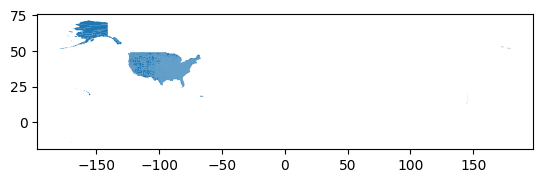

In [31]:
# Take a quick look
us.plot()

<Axes: >

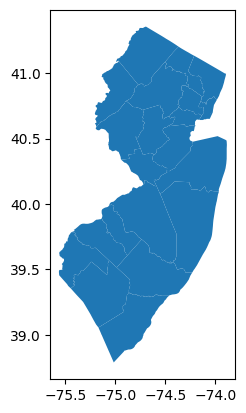

In [32]:
# Filter out NJ
nj = us[us.STATEFP=='34'].copy()
nj.plot()

In [33]:
# Let's say we want to look at the drought severity,
# electricity generation, and emissions across NJ

# As the electricity data we collected is for each plant,
# we can aggregate the total net generation at each county,
# and calculate the averaged emission in tons/MWh to represent the emission invensity
generation = []
emissions = []
for county in counties:
    total_gen = (egrid_processed['Generation(MWh)'][egrid_processed.County==county]).sum()
    generation.append(total_gen)
    total_emissions = (egrid_processed['Emissions(tons)'][egrid_processed.County==county]).sum()
    if total_gen == 0:
        avg = 0
    else: avg = total_emissions/total_gen
    emissions.append(avg)
egrid_agg = pd.DataFrame({
    'County': counties,
    'Generation(MWh)': generation,
    'Emissions(tons/MWh)': emissions,
})
egrid_agg.head()

,County,Generation(MWh),Emissions(tons/MWh)
0,Atlantic,165776.999,0.368140
1,Bergen,2639940.000,0.467585
2,Burlington,296933.000,0.089723
3,Camden,324328.001,0.774194
4,Cape May,0.000,0.000000


In [34]:
# Now let's merge the drought and electricity data
merged_data = drought_avg.merge(egrid_agg, on='County')
merged_data.head()

,FIPS,County,State,Country,DSCI,Generation(MWh),Emissions(tons/MWh)
0,34001,Atlantic,New Jersey,USA,75.519464,165776.999,0.368140
1,34003,Bergen,New Jersey,USA,55.934138,2639940.000,0.467585
2,34005,Burlington,New Jersey,USA,55.092605,296933.000,0.089723
3,34007,Camden,New Jersey,USA,58.714483,324328.001,0.774194
4,34009,Cape May,New Jersey,USA,87.965785,0.000,0.000000


In [35]:
# Merge in the geo info
nj['FIPS'] = (nj.STATEFP + nj.COUNTYFP).astype('int64')
nj = nj.merge(merged_data, on='FIPS')

<Axes: >

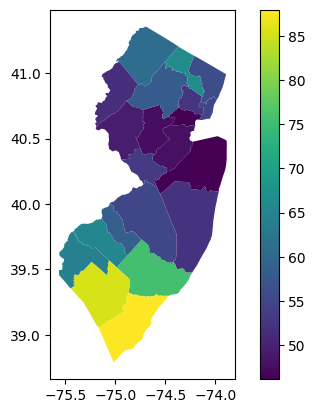

In [36]:
# Plot by drought severity
nj.plot(column='DSCI', legend=True)

<Axes: >

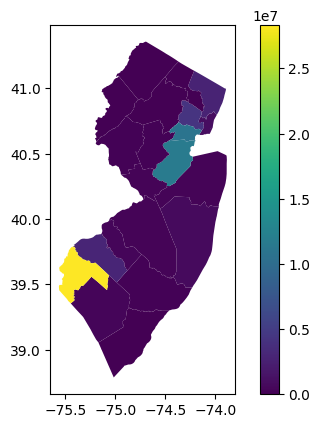

In [37]:
# Plot by net electricity generation
nj.plot(column='Generation(MWh)', legend=True)

<Axes: >

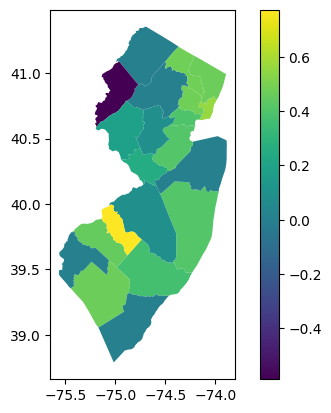

In [38]:
# Plot by emissions
nj.plot(column='Emissions(tons/MWh)', legend=True)

In [39]:
# Formatting in Python isn't that easy!
# So let's export the data and use ArcGIS to make it much nicer
# Note that we need to export as shapefile so that ArcGIS can import it correctly
nj.to_file('../data/3_CompiledData.geojson', driver='GeoJSON')